# Customer Churn Prediction Using Machine Learning

## Project Objective

The objective of this project is to predict whether a customer is likely to leave the bank (churn) based on customer information such as age, credit score, account balance, products, and activity status.

This project follows the complete Machine Learning workflow used in the industry, including:

- Business Understanding
- Data Understanding
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation
- Hyperparameter Tuning
- Model Deployment

**Target Variable:** Churn

**Problem Type:** Binary Classification

# Business Understanding

Customer churn is one of the biggest challenges for banks and telecom companies.

When customers leave, companies lose revenue and spend more money acquiring new customers.

Using Machine Learning, we can predict customers who are likely to leave in advance.

This enables the business to:

- Improve customer retention
- Reduce revenue loss
- Offer personalized discounts
- Increase customer satisfaction

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

# Path to your file in Drive
file_path = '/content/drive/MyDrive/customer_data.csv'

df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Dataset Overview

Before applying any Machine Learning algorithm, it is important to understand the dataset.

In this section, we will explore:

- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Basic statistics

In [ ]:
print("="*50)
print("Number of rows and columns")
print("="*50)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("="*50)
print("Data types")
print("="*50)
print(df.dtypes)

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("="*50)
print("Duplicated Records")
print("="*50)
print(df.duplicated().sum())

print("="*50)
print("Basic Statistics")
print("="*50)
print(df.describe())

Number of rows and columns
Number of rows: 10000
Number of columns: 12
Data types
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
Missing Values
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
Duplicated Records
0
Basic Statistics
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288  

# Data Quality Checks

Before cleaning the dataset, we need to validate whether the data is logically correct.

In this section we will check:

- Unique values
- Invalid values
- Target distribution
- Numerical column ranges
- Categorical values

In [ ]:
print("="*50)
print("Unique Values in each columns")
print("="*50)
print(df.nunique())

Unique Values in each columns
customer_id         10000
credit_score          460
country                 0
gender                  2
age                    56
tenure                 11
balance              6382
products_number         4
credit_card             2
active_member           2
estimated_salary     9999
churn                   2
dtype: int64


In [ ]:
print("="*60)
print("Country Distribution")
print("="*60)

print(df["country"].value_counts())


print("="*60)
print("Gender Distribution")
print("="*60)

print(df["gender"].value_counts())

Country Distribution
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender Distribution
gender
Male      5457
Female    4543
Name: count, dtype: int64


In [ ]:
print("="*60)
print("Target Variable Distribution")
print("="*60)

print(df["churn"].value_counts())


print("\nPercentage Distribution\n")

print(round(df["churn"].value_counts(normalize=True)*100,2))

Target Variable Distribution
churn
0    7963
1    2037
Name: count, dtype: int64

Percentage Distribution

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
print("="*60)
print("Customer ID Validation")
print("="*60)

print("Unique Customer IDs :", df["customer_id"].nunique())

Customer ID Validation
Unique Customer IDs : 10000


In [ ]:
print("="*60)
print("Minimum and Maximum Values")
print("="*60)

print("Age :", df["age"].min(), "-", df["age"].max())
print("Credit Score :", df["credit_score"].min(), "-", df["credit_score"].max())
print("Tenure :", df["tenure"].min(), "-", df["tenure"].max())
print("Balance :", df["balance"].min(), "-", df["balance"].max())
print("Estimated Salary :", df["estimated_salary"].min(), "-", df["estimated_salary"].max())

Minimum and Maximum Values
Age : 18 - 92
Credit Score : 350 - 850
Tenure : 0 - 10
Balance : 0.0 - 250898.09
Estimated Salary : 11.58 - 199992.48


## Data Cleaning Summary

After performing data quality checks, the following observations were made:

- No missing values were found.
- No duplicate records were found.
- All numerical columns have valid data types.
- Categorical columns are clean and contain valid categories.
- The `customer_id` column is a unique identifier and will be removed before model training.
- The `country` and `gender` columns will be encoded during preprocessing.

**Conclusion:** The dataset is clean and ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

## Target Variable Analysis

The objective of this section is to understand the distribution of the target variable (`churn`).

Business Question:

- How many customers stayed?
- How many customers left?
- Is the dataset balanced or imbalanced?

/tmp/ipykernel_913/708637135.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])


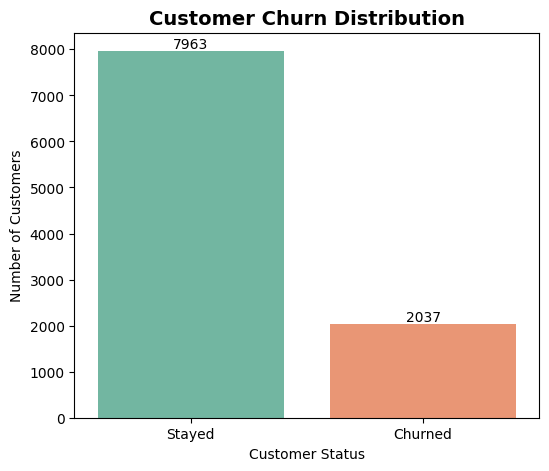

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="churn",
    hue="churn",
    palette="Set2",
    legend=False
)

# Change x-axis labels
ax.set_xticklabels(["Stayed", "Churned"])

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Age Analysis

In this section, we will analyze the distribution of customer age and understand its relationship with customer churn.

Business Questions:
- What is the age distribution of customers?
- Are older customers more likely to churn?

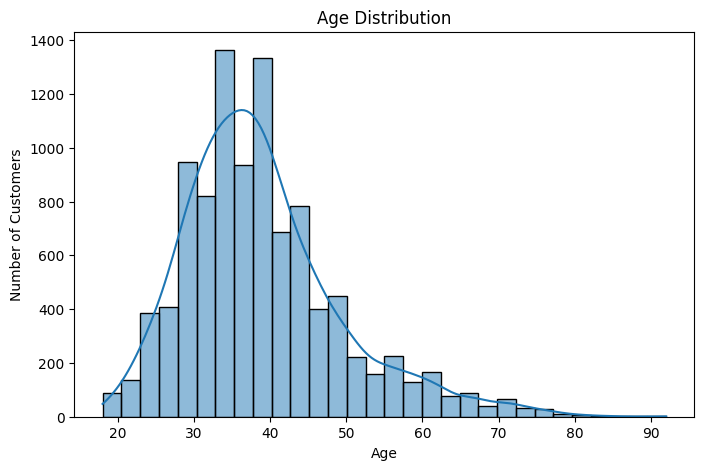

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

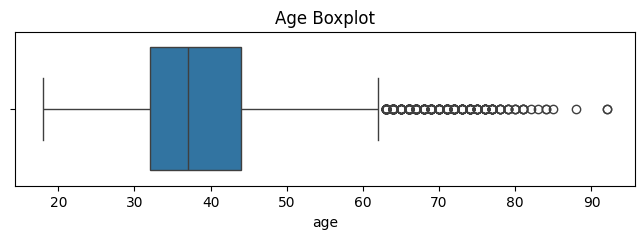

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["age"]
)

plt.title("Age Boxplot")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

/tmp/ipykernel_913/1134972976.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed","Churned"])


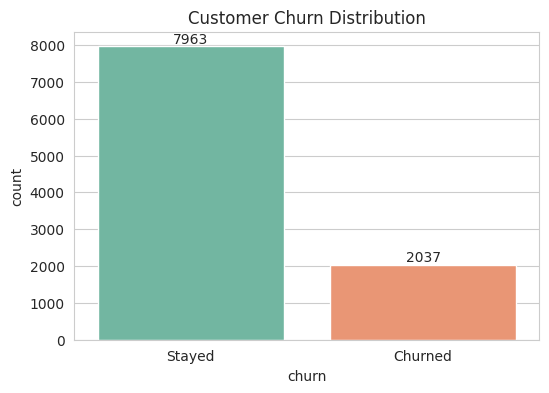

In [ ]:
# Target Variable Analysis

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="churn",
    hue="churn",
    palette="Set2",
    legend=False
)

ax.set_xticklabels(["Stayed","Churned"])

plt.title("Customer Churn Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

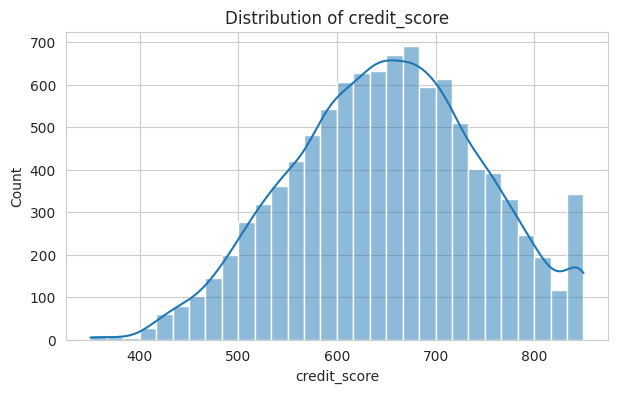

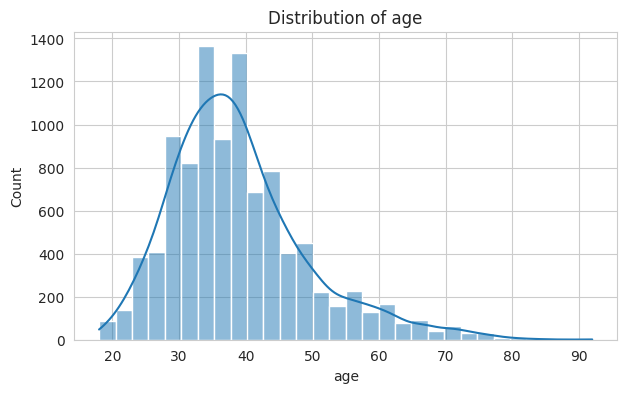

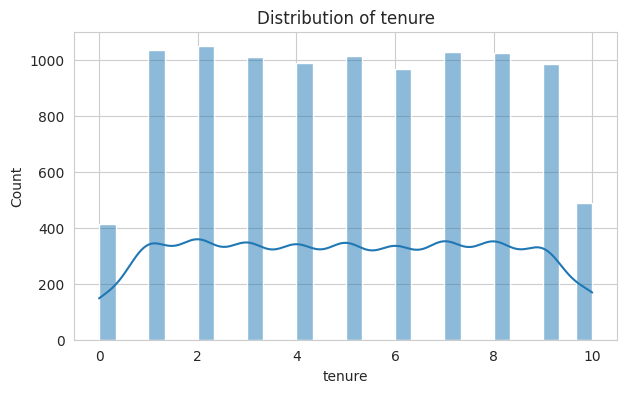

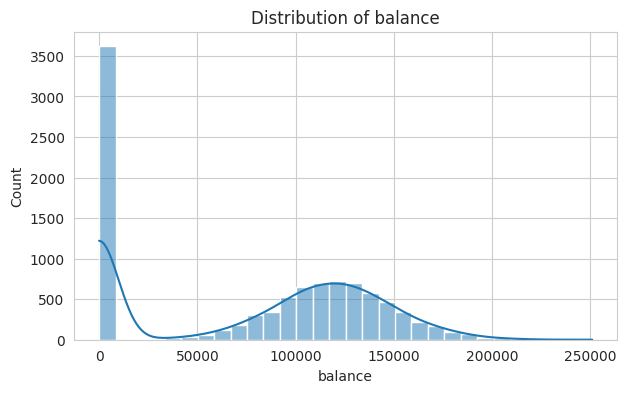

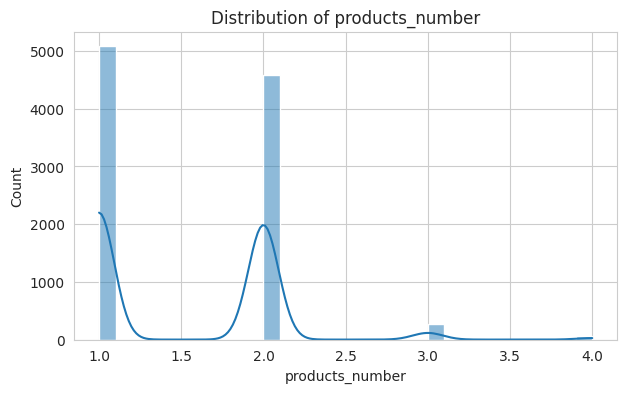

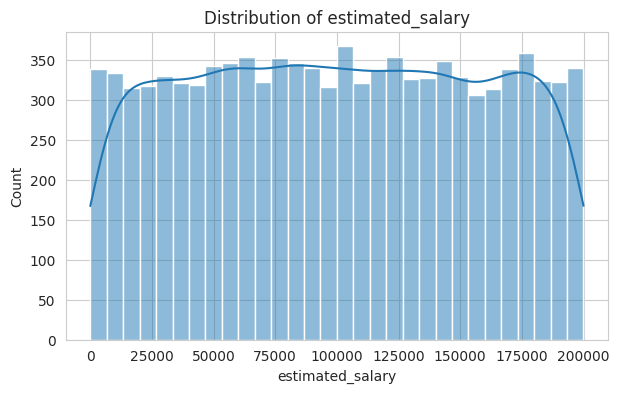

In [ ]:
# Numerical Features Distribution

numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(f"Distribution of {col}")

    plt.show()

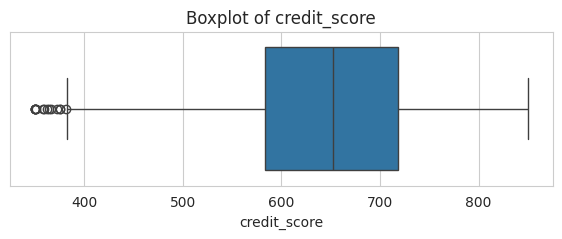

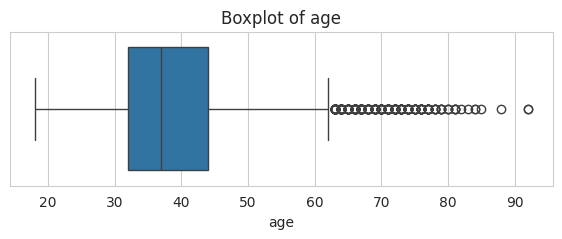

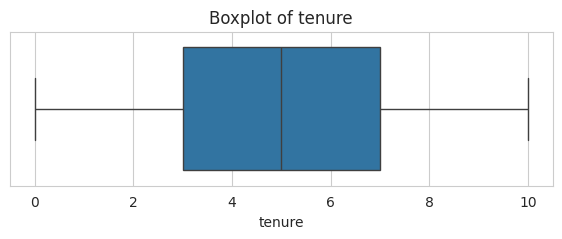

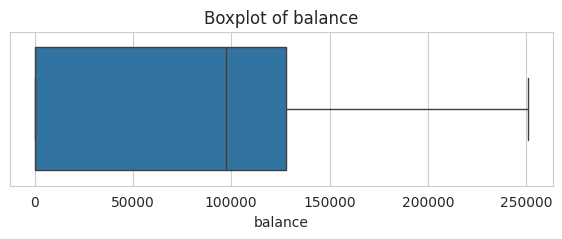

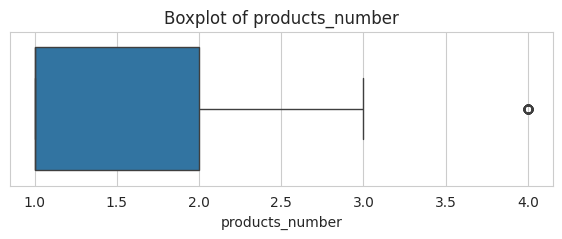

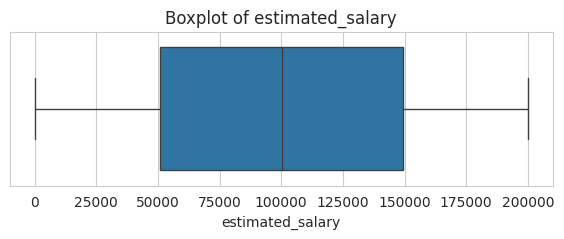

In [ ]:
for col in numerical_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

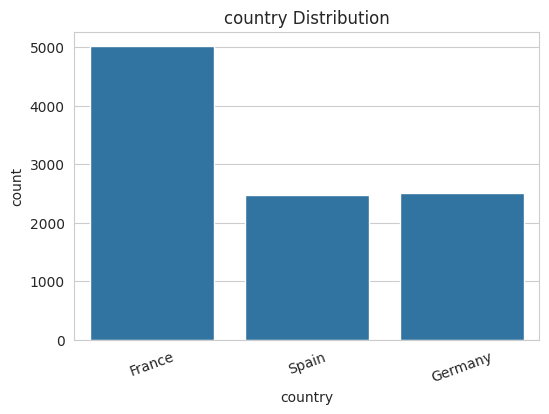

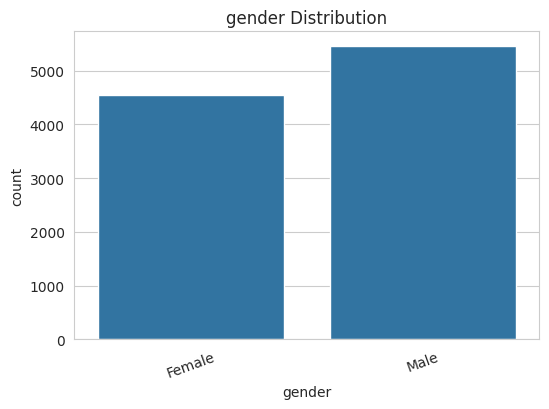

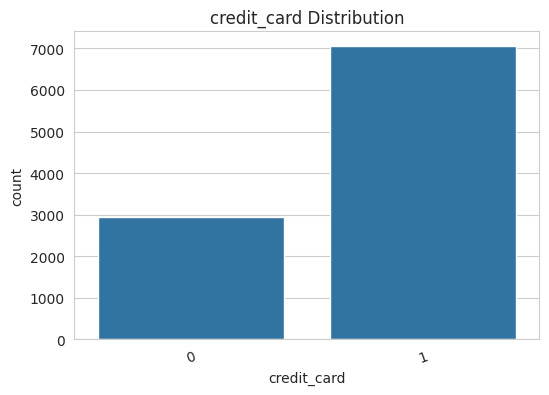

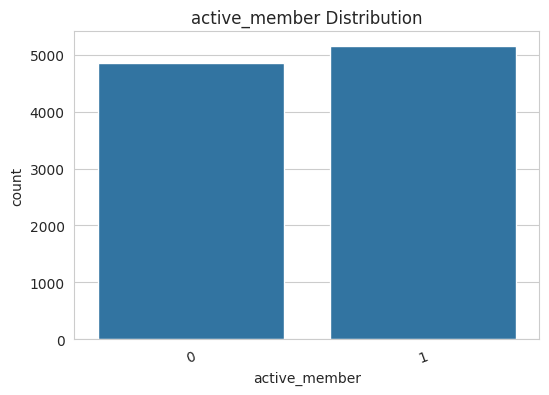

In [ ]:
# Categorical Features

categorical_columns = [
    "country",
    "gender",
    "credit_card",
    "active_member"
]

for col in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df,x=col)

    plt.title(f"{col} Distribution")

    plt.xticks(rotation=20)

    plt.show()

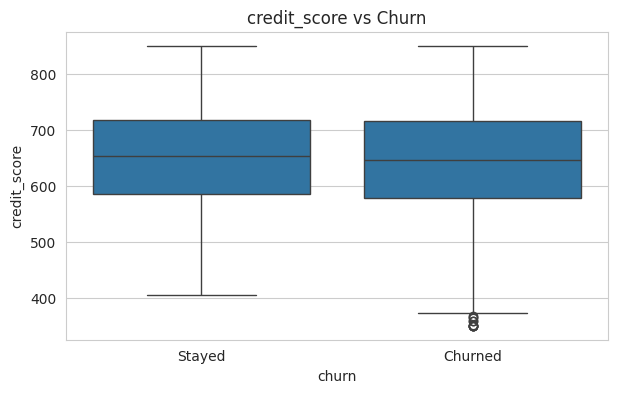

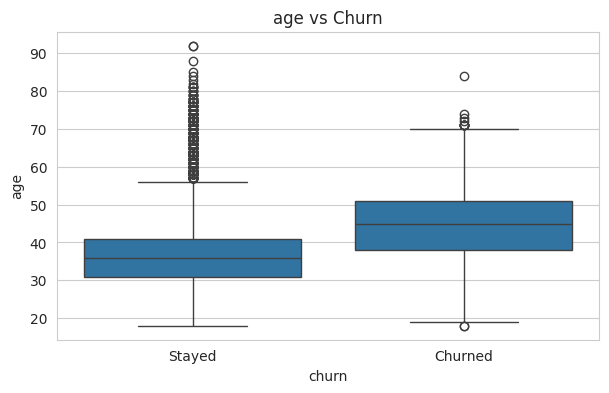

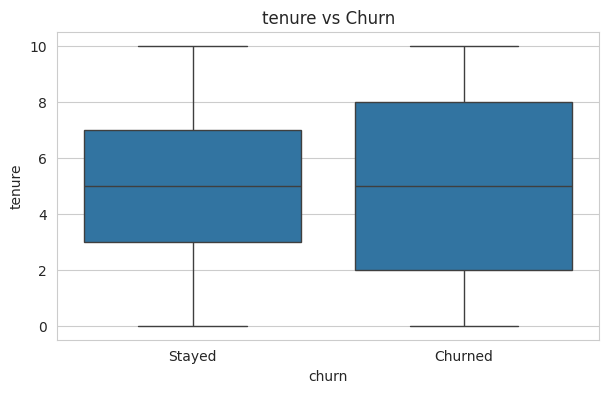

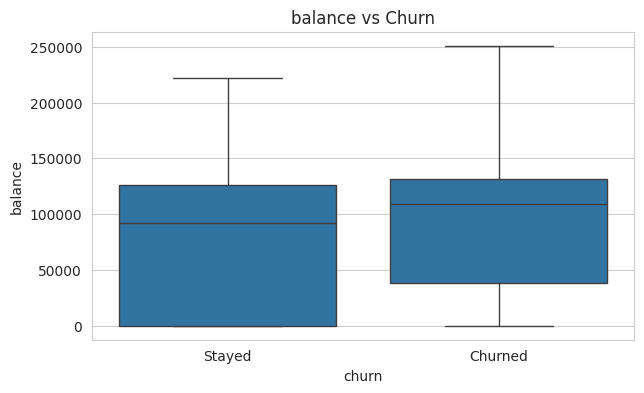

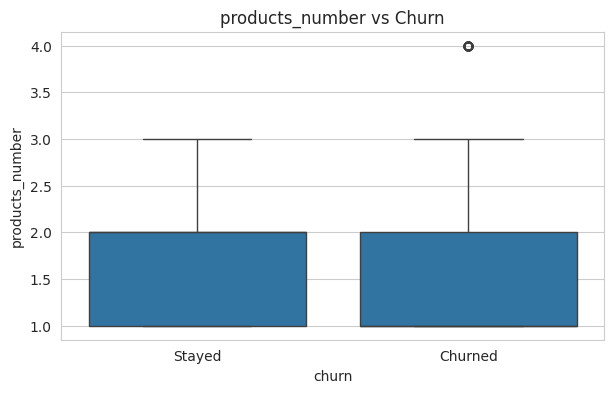

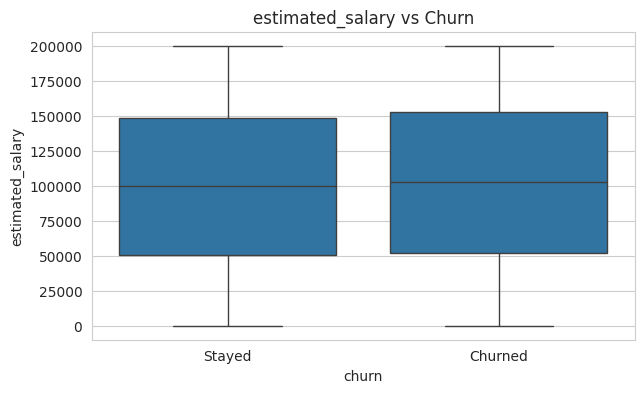

In [ ]:
# Numerical Features vs Churn

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="churn",
        y=col
    )

    plt.title(f"{col} vs Churn")

    plt.xticks([0,1],["Stayed","Churned"])

    plt.show()

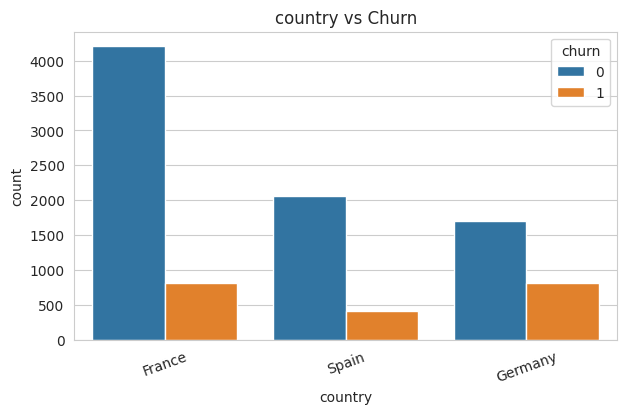

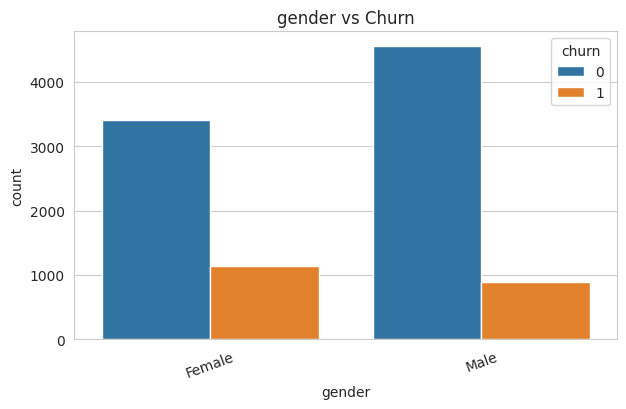

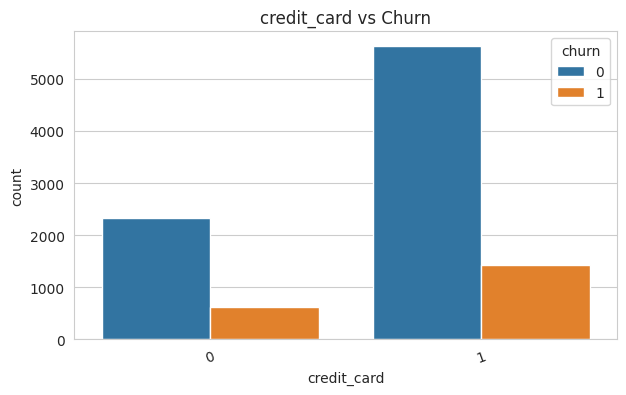

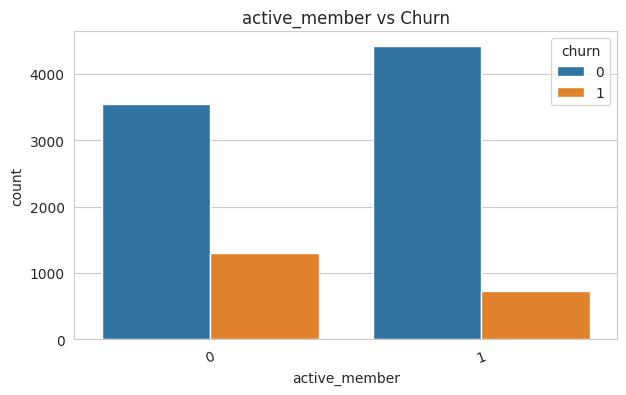

In [ ]:
# Categorical Features vs Churn

for col in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="churn"
    )

    plt.title(f"{col} vs Churn")

    plt.xticks(rotation=20)

    plt.show()

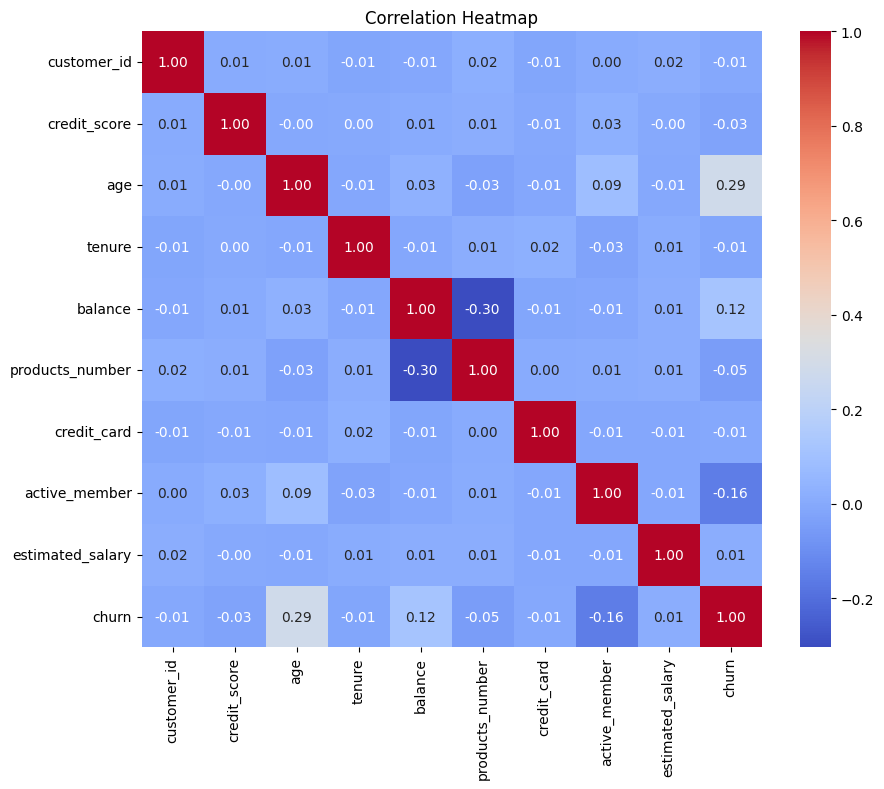

In [6]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [7]:
# Remove customer_id because it is only an identifier

df = df.drop("customer_id", axis=1)

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Features (Independent Variables)

X = df.drop("churn", axis=1)

# Target (Dependent Variable)

y = df["churn"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (10000, 10)
Shape of y : (10000,)


In [9]:
print(X.dtypes)

credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
dtype: object


In [10]:
X = pd.get_dummies(
    X,
    columns=["country", "gender"],
    drop_first=True,
    dtype=int
)

X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [11]:
print(X.columns)

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary', 'country_Germany',
       'country_Spain', 'gender_Male'],
      dtype='object')


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (8000, 11)
Testing Data : (2000, 11)


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

In [16]:
X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [17]:
X_train.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,1,0,1.042084,0,0,1
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,1,0,-0.623556,1,0,1
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,1,1,0.308128,1,0,0
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,1,0,-0.290199,0,0,1
7182,0.427035,0.955079,0.339492,0.548318,0.808830,0,1,0.135042,1,0,1


In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [22]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.808
Precision : 0.5891472868217055
Recall : 0.18673218673218672
F1 Score : 0.2835820895522388
[[1540   53]
 [ 331   76]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



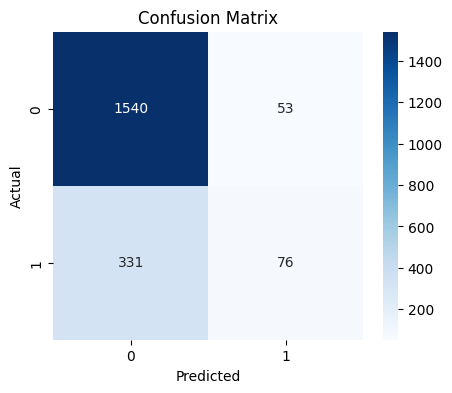

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, probabilities)

print("ROC AUC Score :", roc_score)

ROC AUC Score : 0.774824130756334


In [25]:
import pickle

pickle.dump(model, open("customer_churn_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))